In [5]:
!pip install ultralytics -q

import os
import random
from glob import glob
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [6]:
random.seed(42)

base_path = "/kaggle/input/datasets/duythanhng/parking-lot-database-for-yolo/PKLotYoloData/HasXML"
sub_dirs = [
    "UFPR04/Sunny/", "UFPR04/Rainy/", "UFPR04/Cloudy/", 
    "UFPR05/Sunny/", "UFPR05/Rainy/", "UFPR05/Cloudy/", 
    "PUCPR/Sunny/", "PUCPR/Rainy/", "PUCPR/Cloudy/"
]

all_images = []

for sub in sub_dirs:
    search_path = os.path.join(base_path, sub, "**", "*.jpg")
    found_images = glob(search_path, recursive=True)
    all_images.extend(found_images)

print(f"Total raw images found: {len(all_images)}")
valid_images = []
for img_path in all_images:
    txt_path = img_path.replace('.jpg', '.txt')
    if os.path.exists(txt_path):
        valid_images.append(img_path)

print(f"Images with valid .txt annotations: {len(valid_images)}")

random.shuffle(valid_images)
split_idx = int(len(valid_images) * 0.8)

train_images = valid_images[:split_idx]
val_images = valid_images[split_idx:]

train_txt = "/kaggle/working/train.txt"
val_txt = "/kaggle/working/val.txt"

with open(train_txt, "w") as f:
    f.write("\n".join(train_images))
    
with open(val_txt, "w") as f:
    f.write("\n".join(val_images))

print(f"Train images saved to {train_txt}: {len(train_images)}")
print(f"Val images saved to {val_txt}: {len(val_images)}")

Total raw images found: 6234
Images with valid .txt annotations: 6234
Train images saved to /kaggle/working/train.txt: 4987
Val images saved to /kaggle/working/val.txt: 1247


In [7]:
yaml_content = f"""
train: {train_txt}
val: {val_txt}

# Number of classes
nc: 2

# Class names (0: Empty space, 1: Occupied space)
names: ['Empty', 'Occupied']
"""

yaml_path = "/kaggle/working/parking_data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"YAML configuration file at: {yaml_path}")

YAML configuration file at: /kaggle/working/parking_data.yaml


In [8]:
model = YOLO('yolo11m.pt')
results = model.train(
    data=yaml_path,
    epochs=50,             
    imgsz=640,             
    batch=32,              
    device=[0, 1],        
    patience=10,           
    cache=True,        
    project='/kaggle/working/',
    name='yolo11_parking_max_perf' 
)

print("Training done")

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/parking_data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_parking_ma

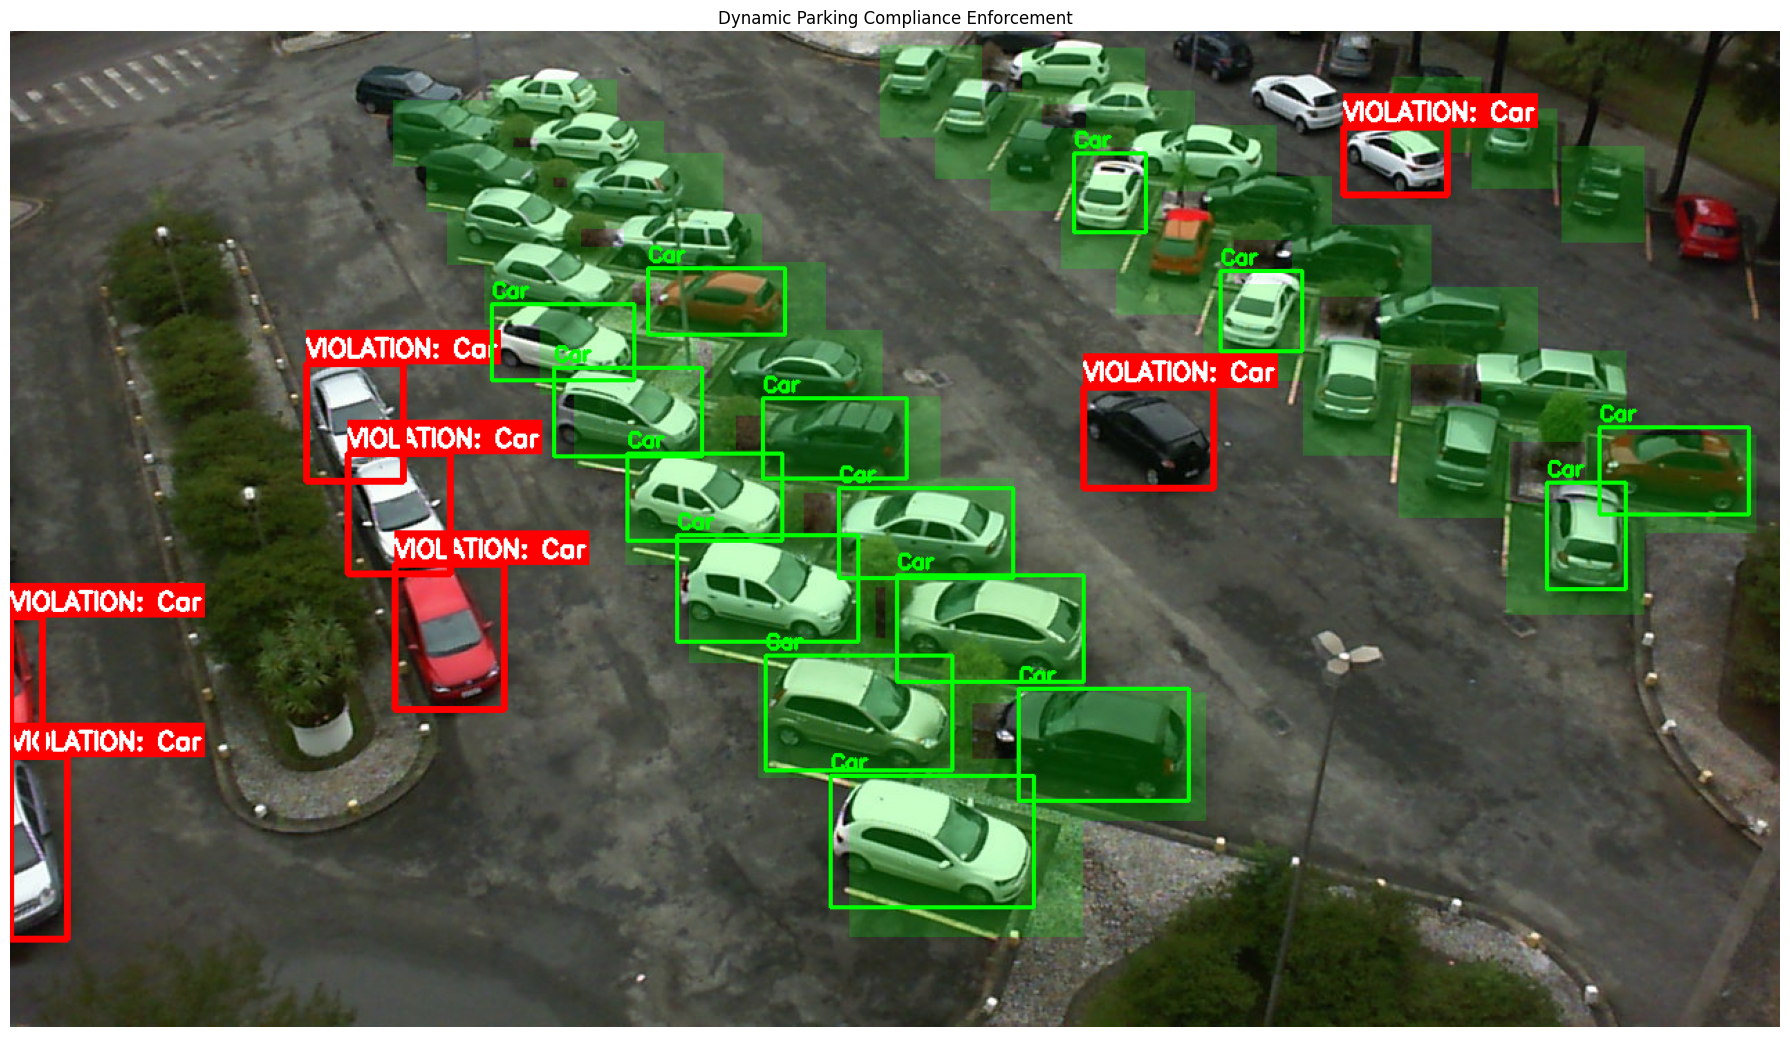

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO

spot_model = YOLO('/kaggle/working/yolo11_parking_max_perf/weights/best.pt') 
vehicle_model = YOLO('yolo11m.pt') 

sample_img_path = random.choice(val_images)
img = cv2.imread(sample_img_path)
overlay = img.copy()

spot_results = spot_model.predict(source=img, conf=0.4, verbose=False)
legal_spots = spot_results[0].boxes.xyxy.cpu().numpy() 

for (sx1, sy1, sx2, sy2) in legal_spots:
    cv2.rectangle(overlay, (int(sx1), int(sy1)), (int(sx2), int(sy2)), (0, 255, 0), -1)

cv2.addWeighted(overlay, 0.2, img, 0.8, 0, img)

vehicle_results = vehicle_model.predict(source=img, conf=0.35, verbose=False)
vehicle_classes = {2: 'Car', 3: 'Motorcycle', 5: 'Bus', 7: 'Truck'}

for v_box in vehicle_results[0].boxes:
    cls_id = int(v_box.cls[0].item())
    
    if cls_id in vehicle_classes:
        v_type = vehicle_classes[cls_id]
        vx1, vy1, vx2, vy2 = map(int, v_box.xyxy[0])
        conf = float(v_box.conf[0]) * 100
        
        contact_x = (vx1 + vx2) // 2
        contact_y = int(vy2 - (vy2 - vy1) * 0.1) 
        
        is_legal = False
        margin = 15 
        for (sx1, sy1, sx2, sy2) in legal_spots:
            if (sx1 - margin < contact_x < sx2 + margin) and (sy1 - margin < contact_y < sy2 + margin):
                is_legal = True
                break
        
        if is_legal:
            cv2.rectangle(img, (vx1, vy1), (vx2, vy2), (0, 255, 0), 2)
            cv2.putText(img, f"{v_type}", (vx1, vy1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        else:
            cv2.rectangle(img, (vx1, vy1), (vx2, vy2), (0, 0, 255), 3)
            label = f"VIOLATION: {v_type}"
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (vx1, vy1 - h - 10), (vx1 + w, vy1), (0, 0, 255), -1)
            cv2.putText(img, label, (vx1, vy1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

plt.figure(figsize=(18, 14))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Dynamic Parking Compliance Enforcement")
plt.tight_layout()
plt.show()